# TFM - Detección y clasificación automática de ciberacoso en redes sociales mediante Machine Learning

## Notebook 02 - Procesamiento, Feature Engineering y experimentación con modelos

### Objetivo

El objetivo de este notebook es desarrollar y comparar diferentes modelos de Machine Learning clásico capaces de clasificar automáticamente mensajes de redes sociales en seis categorías relacionadas con el ciberacoso.

A partir del dataset previamente analizado y depurado durante el EDA, se realizarán las siguientes etapas:

1. Preparación del conjunto de datos.
2. División en conjuntos de entrenamiento y prueba.
3. Transformación del texto en características numéricas mediante técnicas de Procesamiento del Lenguaje Natural.
4. Evaluación de diferentes estrategias de representación del texto.
5. Entrenamiento y comparación de varios algoritmos de Machine Learning.
6. Evaluación mediante métricas adecuadas para clasificación multiclase.
7. Optimización del modelo seleccionado.
8. Análisis de errores y matriz de confusión.
9. Entrenamiento y almacenamiento del modelo final para su posterior utilización en la aplicación desarrollada con Streamlit.

El objetivo final es seleccionar un modelo que ofrezca un buen equilibrio entre capacidad predictiva, eficiencia, interpretabilidad y facilidad de despliegue.

In [1]:
# ----------------------------------------------------------
# IMPORTACIÓN DE LIBRERÍAS
# ----------------------------------------------------------

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Descarga del dataset desde Kaggle
import kagglehub

# División de los datos
from sklearn.model_selection import train_test_split

# Representación numérica del texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Construcción de pipelines
from sklearn.pipeline import Pipeline

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configuración de pandas para visualizar mejor los textos
pd.set_option("display.max_colwidth", 150)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# ----------------------------------------------------------
# CARGA DEL DATASET
# ----------------------------------------------------------

import os

# Descargamos el dataset desde Kaggle.
path = kagglehub.dataset_download(
    "andrewmvd/cyberbullying-classification"
)

# Construimos la ruta del archivo CSV.
file_path = os.path.join(
    path,
    "cyberbullying_tweets.csv"
)

# Cargamos los datos.
df = pd.read_csv(file_path)

print("Dimensiones originales:", df.shape)

df.head()

Using Colab cache for faster access to the 'cyberbullying-classification' dataset.
Dimensiones originales: (47692, 2)


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was crapilicious! #mkr",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, but not too concerned about another angry dude on twitter.",not_cyberbullying
4,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",not_cyberbullying


## Preparación del dataset

Durante el análisis exploratorio se detectaron textos duplicados y mensajes idénticos asociados a diferentes categorías.

Dado que no se dispone de una fuente externa que permita determinar cuál de las etiquetas contradictorias es la correcta, se decidió eliminar los textos asociados a más de una categoría y, posteriormente, eliminar los duplicados restantes.

Esta estrategia permite trabajar con un conjunto de entrenamiento con mayor consistencia en las etiquetas y reduce el ruido que podría afectar al aprendizaje supervisado.

In [3]:
# ----------------------------------------------------------
# LIMPIEZA DE INCONSISTENCIAS Y DUPLICADOS
# ----------------------------------------------------------

# Calculamos cuántas categorías diferentes tiene asociado
# cada texto.
num_etiquetas_por_texto = (
    df.groupby("tweet_text")["cyberbullying_type"]
      .nunique()
)

# Identificamos los textos asociados a más de una categoría.
textos_conflictivos = set(
    num_etiquetas_por_texto[
        num_etiquetas_por_texto > 1
    ].index
)

# Eliminamos todos los registros correspondientes
# a esos textos conflictivos.
df = df[
    ~df["tweet_text"].isin(textos_conflictivos)
].copy()

# Eliminamos los textos duplicados restantes.
# En este punto los duplicados conservados tienen
# la misma categoría, por lo que basta con mantener
# una única observación.
df = df.drop_duplicates(
    subset=["tweet_text"],
    keep="first"
).reset_index(drop=True)

print("Dimensiones después de la limpieza:", df.shape)

print(
    "Textos duplicados:",
    df["tweet_text"].duplicated().sum()
)

print(
    "Valores nulos:",
    df.isnull().sum().sum()
)

Dimensiones después de la limpieza: (44378, 2)
Textos duplicados: 0
Valores nulos: 0


## Separación de variables y conjuntos de entrenamiento y prueba

Para construir un modelo supervisado es necesario diferenciar entre las variables utilizadas para realizar la predicción y la variable objetivo.

En este proyecto:

- **X (`tweet_text`)** contiene el texto de los mensajes y constituye la información de entrada del modelo.
- **y (`cyberbullying_type`)** contiene la categoría asociada a cada mensaje y constituye la variable objetivo que se desea predecir.

Posteriormente, los datos se dividirán en un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utilizará para ajustar los modelos, mientras que el conjunto de prueba se reservará para evaluar su capacidad de clasificación sobre observaciones que no hayan sido utilizadas durante el entrenamiento.

In [4]:
# ----------------------------------------------------------
# SEPARACIÓN DE VARIABLES
# ----------------------------------------------------------

# X contiene los textos que utilizará el modelo
# como información de entrada.
X = df["tweet_text"]

# y contiene la categoría que queremos predecir.
y = df["cyberbullying_type"]

print("Número de observaciones en X:", len(X))
print("Número de observaciones en y:", len(y))

print("\nCategorías:")
print(y.value_counts())

Número de observaciones en X: 44378
Número de observaciones en y: 44378

Categorías:
cyberbullying_type
age                    7992
religion               7991
ethnicity              7952
gender                 7772
not_cyberbullying      6428
other_cyberbullying    6243
Name: count, dtype: int64


In [5]:
# ----------------------------------------------------------
# DIVISIÓN TRAIN / TEST
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,

    # Reservamos el 20 % de los datos para evaluación.
    test_size=0.20,

    # Conservamos aproximadamente la misma proporción
    # de las seis categorías en train y test.
    stratify=y,

    # Fijamos una semilla para que la división pueda
    # reproducirse al volver a ejecutar el notebook.
    random_state=42
)

print("Observaciones de entrenamiento:", len(X_train))
print("Observaciones de test:", len(X_test))

print(
    "\nPorcentaje de entrenamiento:",
    round(len(X_train) / len(X) * 100, 2),
    "%"
)

print(
    "Porcentaje de test:",
    round(len(X_test) / len(X) * 100, 2),
    "%"
)

Observaciones de entrenamiento: 35502
Observaciones de test: 8876

Porcentaje de entrenamiento: 80.0 %
Porcentaje de test: 20.0 %


In [6]:
# ----------------------------------------------------------
# COMPROBACIÓN DE LA ESTRATIFICACIÓN
# ----------------------------------------------------------

distribucion_train = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

distribucion_test = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

comparacion_distribucion = pd.DataFrame({
    "Train (%)": distribucion_train,
    "Test (%)": distribucion_test
})

comparacion_distribucion

,Train (%),Test (%)
cyberbullying_type,,
age,18.01,18.01
ethnicity,17.92,17.91
gender,17.51,17.51
not_cyberbullying,14.48,14.49
other_cyberbullying,14.07,14.07
religion,18.01,18.00


## Estrategia de representación y experimentación

Los algoritmos clásicos de Machine Learning requieren una representación numérica de los datos de entrada. Por este motivo, los mensajes se transformarán mediante TF-IDF (*Term Frequency - Inverse Document Frequency*).

Para evitar fuga de información (*data leakage*), la transformación TF-IDF y el clasificador se integrarán dentro de un `Pipeline` de Scikit-learn. De esta forma, el vectorizador se ajustará exclusivamente utilizando los datos de entrenamiento.

El análisis exploratorio mostró que tanto las palabras individuales como determinadas combinaciones de dos palabras pueden contener información relevante. Por este motivo, durante la experimentación se podrán comparar diferentes configuraciones de TF-IDF, incluyendo unigramas y combinaciones de unigramas y bigramas.

Se evaluarán diferentes algoritmos de Machine Learning clásico y se comparará su rendimiento mediante métricas adecuadas para clasificación multiclase.

Además de la capacidad predictiva, se tendrán en cuenta aspectos como el tiempo de entrenamiento, la interpretabilidad, la complejidad y la facilidad de despliegue del modelo final.

In [7]:
# ----------------------------------------------------------
# PRIMER MODELO: REGRESIÓN LOGÍSTICA + TF-IDF
# ----------------------------------------------------------

from sklearn.linear_model import LogisticRegression

# Construimos un pipeline que integra:
#
# 1. Transformación del texto mediante TF-IDF.
# 2. Clasificación mediante Regresión Logística.
#
# En este primer modelo utilizamos unigramas
# (palabras individuales) como representación inicial.

pipeline_logistic = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 1),
            min_df=5,
            max_features=20000
        )
    ),

    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [8]:
# ----------------------------------------------------------
# ENTRENAMIENTO
# ----------------------------------------------------------

import time

inicio = time.time()

pipeline_logistic.fit(
    X_train,
    y_train
)

tiempo_entrenamiento = (
    time.time() - inicio
)

print(
    "Tiempo de entrenamiento:",
    round(tiempo_entrenamiento, 2),
    "segundos"
)

Tiempo de entrenamiento: 7.75 segundos


In [9]:
# ----------------------------------------------------------
# PREDICCIONES SOBRE EL CONJUNTO DE TEST
# ----------------------------------------------------------

y_pred_logistic = pipeline_logistic.predict(
    X_test
)

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

f1_macro_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

print(
    "Accuracy:",
    round(accuracy_logistic, 4)
)

print(
    "F1 Macro:",
    round(f1_macro_logistic, 4)
)

Accuracy: 0.8748
F1 Macro: 0.8636


### Modelo 2 - Multinomial Naive Bayes

Multinomial Naive Bayes es un algoritmo probabilístico utilizado habitualmente en problemas de clasificación de texto.

Su simplicidad y velocidad lo convierten en un modelo de referencia útil para comparar el rendimiento obtenido mediante TF-IDF con otros algoritmos de clasificación.

Para mantener una comparación inicial homogénea, se utilizará la misma configuración TF-IDF empleada en el primer modelo.

In [10]:
# ----------------------------------------------------------
# SEGUNDO MODELO: MULTINOMIAL NAIVE BAYES + TF-IDF
# ----------------------------------------------------------

from sklearn.naive_bayes import MultinomialNB

# Construimos un nuevo Pipeline utilizando exactamente
# la misma configuración TF-IDF del primer experimento.
#
# De esta forma, la principal diferencia entre ambos
# experimentos será el algoritmo de clasificación.

pipeline_nb = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 1),
            min_df=5,
            max_features=20000
        )
    ),

    (
        "modelo",
        MultinomialNB()
    )
])

print("Pipeline de Multinomial Naive Bayes creado correctamente.")

Pipeline de Multinomial Naive Bayes creado correctamente.


In [11]:
# ----------------------------------------------------------
# ENTRENAMIENTO DE MULTINOMIAL NAIVE BAYES
# ----------------------------------------------------------

inicio = time.time()

pipeline_nb.fit(
    X_train,
    y_train
)

tiempo_nb = time.time() - inicio

print(
    "Tiempo de entrenamiento:",
    round(tiempo_nb, 2),
    "segundos"
)

Tiempo de entrenamiento: 3.76 segundos


In [12]:
# ----------------------------------------------------------
# PREDICCIONES Y EVALUACIÓN INICIAL
# ----------------------------------------------------------

y_pred_nb = pipeline_nb.predict(
    X_test
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

f1_macro_nb = f1_score(
    y_test,
    y_pred_nb,
    average="macro"
)

print(
    "Accuracy:",
    round(accuracy_nb, 4)
)

print(
    "F1 Macro:",
    round(f1_macro_nb, 4)
)

Accuracy: 0.806
F1 Macro: 0.7784


### Modelo 3 - Linear Support Vector Machine (Linear SVM)

Linear SVM es un algoritmo de clasificación especialmente adecuado para problemas con un gran número de características, como ocurre en la representación TF-IDF de textos.

El algoritmo busca construir fronteras de decisión que permitan separar las diferentes categorías maximizando el margen entre ellas.

Para mantener una comparación homogénea con los modelos anteriores, se utilizará inicialmente la misma configuración TF-IDF.

In [13]:
# ----------------------------------------------------------
# TERCER MODELO: LINEAR SVM + TF-IDF
# ----------------------------------------------------------

from sklearn.svm import LinearSVC

# Utilizamos nuevamente la misma configuración TF-IDF
# para que la comparación con los modelos anteriores
# sea lo más homogénea posible.

pipeline_svm = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 1),
            min_df=5,
            max_features=20000
        )
    ),

    (
        "modelo",
        LinearSVC(
            random_state=42
        )
    )
])

print("Pipeline de Linear SVM creado correctamente.")

Pipeline de Linear SVM creado correctamente.


In [14]:
# ----------------------------------------------------------
# ENTRENAMIENTO DE LINEAR SVM
# ----------------------------------------------------------

inicio = time.time()

pipeline_svm.fit(
    X_train,
    y_train
)

tiempo_svm = time.time() - inicio

print(
    "Tiempo de entrenamiento:",
    round(tiempo_svm, 2),
    "segundos"
)

Tiempo de entrenamiento: 4.03 segundos


In [15]:
# ----------------------------------------------------------
# PREDICCIONES Y EVALUACIÓN INICIAL
# ----------------------------------------------------------

y_pred_svm = pipeline_svm.predict(
    X_test
)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

f1_macro_svm = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print(
    "Accuracy:",
    round(accuracy_svm, 4)
)

print(
    "F1 Macro:",
    round(f1_macro_svm, 4)
)

Accuracy: 0.8707
F1 Macro: 0.8578


In [16]:
# ----------------------------------------------------------
# COMPARACIÓN DE LOS MODELOS BASE
# ----------------------------------------------------------

resultados_base = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_nb,
        accuracy_svm
    ],
    "F1 Macro": [
        f1_macro_logistic,
        f1_macro_nb,
        f1_macro_svm
    ],
    "Tiempo entrenamiento (s)": [
        tiempo_entrenamiento,
        tiempo_nb,
        tiempo_svm
    ]
})

# Ordenamos los modelos de mayor a menor F1 Macro.
resultados_base = resultados_base.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

resultados_base.round(4)

,Modelo,Accuracy,F1 Macro,Tiempo entrenamiento (s)
0,Regresión Logística,0.8748,0.8636,7.7498
1,Linear SVM,0.8707,0.8578,4.0290
2,Multinomial Naive Bayes,0.8060,0.7784,3.7594


### Conclusiones de los modelos base

Los tres algoritmos fueron evaluados utilizando la misma división de entrenamiento y prueba y la misma configuración inicial de TF-IDF, permitiendo realizar una comparación homogénea.

La Regresión Logística obtuvo el mejor rendimiento inicial, con un Accuracy de 0,8748 y un F1 Macro de 0,8636. Linear SVM presentó resultados muy próximos, con un Accuracy de 0,8707 y un F1 Macro de 0,8578, además de un menor tiempo de entrenamiento.

Multinomial Naive Bayes fue el algoritmo más rápido, pero presentó una reducción apreciable en las métricas predictivas respecto a los otros dos modelos.

A partir de estos resultados, la Regresión Logística y Linear SVM se consideran los principales candidatos para la siguiente fase de experimentación.

## Experimentación con unigramas y bigramas

El análisis exploratorio mostró la presencia de combinaciones de palabras características en diferentes categorías. Por este motivo, se realiza un segundo experimento incorporando tanto unigramas como bigramas en la representación TF-IDF.

Para controlar el coste computacional derivado del aumento del número de características, se establece un límite máximo de 30.000 características.

La experimentación se realiza sobre los dos algoritmos que obtuvieron mejores resultados en la comparación inicial: Regresión Logística y Linear SVM.

In [17]:
# ----------------------------------------------------------
# REGRESIÓN LOGÍSTICA:
# TF-IDF CON UNIGRAMAS + BIGRAMAS
# ----------------------------------------------------------

pipeline_logistic_bigram = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",

            # Incluimos palabras individuales y
            # combinaciones consecutivas de dos palabras.
            ngram_range=(1, 2),

            min_df=5,

            # Aumentamos el número máximo de características
            # porque ahora pueden existir unigramas y bigramas.
            max_features=30000
        )
    ),

    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

inicio = time.time()

pipeline_logistic_bigram.fit(
    X_train,
    y_train
)

tiempo_logistic_bigram = time.time() - inicio

y_pred_logistic_bigram = (
    pipeline_logistic_bigram.predict(X_test)
)

accuracy_logistic_bigram = accuracy_score(
    y_test,
    y_pred_logistic_bigram
)

f1_logistic_bigram = f1_score(
    y_test,
    y_pred_logistic_bigram,
    average="macro"
)

print(
    "Tiempo de entrenamiento:",
    round(tiempo_logistic_bigram, 2),
    "segundos"
)

print(
    "Accuracy:",
    round(accuracy_logistic_bigram, 4)
)

print(
    "F1 Macro:",
    round(f1_logistic_bigram, 4)
)

Tiempo de entrenamiento: 10.08 segundos
Accuracy: 0.8754
F1 Macro: 0.8641


In [18]:
# ----------------------------------------------------------
# LINEAR SVM:
# TF-IDF CON UNIGRAMAS + BIGRAMAS
# ----------------------------------------------------------

pipeline_svm_bigram = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",

            # Incluimos unigramas y bigramas.
            ngram_range=(1, 2),

            min_df=5,

            # Limitamos el número de características
            # para controlar el coste computacional.
            max_features=30000
        )
    ),

    (
        "modelo",
        LinearSVC(
            random_state=42
        )
    )
])

# Medimos el tiempo de entrenamiento.
inicio = time.time()

pipeline_svm_bigram.fit(
    X_train,
    y_train
)

tiempo_svm_bigram = time.time() - inicio

# Realizamos las predicciones sobre el conjunto de test.
y_pred_svm_bigram = pipeline_svm_bigram.predict(
    X_test
)

# Calculamos las métricas.
accuracy_svm_bigram = accuracy_score(
    y_test,
    y_pred_svm_bigram
)

f1_svm_bigram = f1_score(
    y_test,
    y_pred_svm_bigram,
    average="macro"
)

print(
    "Tiempo de entrenamiento:",
    round(tiempo_svm_bigram, 2),
    "segundos"
)

print(
    "Accuracy:",
    round(accuracy_svm_bigram, 4)
)

print(
    "F1 Macro:",
    round(f1_svm_bigram, 4)
)

Tiempo de entrenamiento: 7.66 segundos
Accuracy: 0.8753
F1 Macro: 0.8628


In [19]:
# ----------------------------------------------------------
# COMPARACIÓN DE TODOS LOS EXPERIMENTOS REALIZADOS
# ----------------------------------------------------------

resultados_experimentos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Regresión Logística",
        "Linear SVM"
    ],

    "Representación": [
        "TF-IDF unigramas",
        "TF-IDF unigramas",
        "TF-IDF unigramas",
        "TF-IDF unigramas + bigramas",
        "TF-IDF unigramas + bigramas"
    ],

    "Accuracy": [
        accuracy_logistic,
        accuracy_nb,
        accuracy_svm,
        accuracy_logistic_bigram,
        accuracy_svm_bigram
    ],

    "F1 Macro": [
        f1_macro_logistic,
        f1_macro_nb,
        f1_macro_svm,
        f1_logistic_bigram,
        f1_svm_bigram
    ],

    "Tiempo entrenamiento (s)": [
        tiempo_entrenamiento,
        tiempo_nb,
        tiempo_svm,
        tiempo_logistic_bigram,
        tiempo_svm_bigram
    ]
})

# Ordenamos de mayor a menor F1 Macro.
resultados_experimentos = (
    resultados_experimentos
    .sort_values(by="F1 Macro", ascending=False)
    .reset_index(drop=True)
)

resultados_experimentos.round(4)

,Modelo,Representación,Accuracy,F1 Macro,Tiempo entrenamiento (s)
0,Regresión Logística,TF-IDF unigramas + bigramas,0.8754,0.8641,10.0816
1,Regresión Logística,TF-IDF unigramas,0.8748,0.8636,7.7498
2,Linear SVM,TF-IDF unigramas + bigramas,0.8753,0.8628,7.6592
3,Linear SVM,TF-IDF unigramas,0.8707,0.8578,4.0290
4,Multinomial Naive Bayes,TF-IDF unigramas,0.8060,0.7784,3.7594


### Selección del modelo candidato

Los experimentos muestran que los mejores resultados se obtienen mediante modelos lineales combinados con representación TF-IDF.

La Regresión Logística con unigramas y bigramas obtuvo el mayor Accuracy (0,8754) y el mayor F1 Macro (0,8641), aunque las diferencias respecto a la Regresión Logística basada únicamente en unigramas y respecto a Linear SVM fueron reducidas.

La incorporación de bigramas produjo una mejora ligera en la Regresión Logística, lo que indica que determinadas combinaciones de palabras aportan información adicional, aunque el incremento de rendimiento no fue elevado.

Multinomial Naive Bayes presentó el menor tiempo de entrenamiento, pero también un rendimiento predictivo claramente inferior.

Considerando conjuntamente el rendimiento, la interpretabilidad y la facilidad de integración en la posterior aplicación, se selecciona la Regresión Logística como principal candidata para la fase de optimización.

En la siguiente etapa se realizará una búsqueda controlada de hiperparámetros utilizando únicamente el conjunto de entrenamiento, evitando utilizar el conjunto de test durante el proceso de selección.

## Optimización de hiperparámetros

Tras comparar los diferentes modelos y representaciones, se seleccionó la Regresión Logística como principal candidata para la optimización.

Para seleccionar los hiperparámetros sin utilizar repetidamente el conjunto de test, se empleará `GridSearchCV` sobre el conjunto de entrenamiento.

La búsqueda evaluará diferentes valores del parámetro de regularización `C` de la Regresión Logística y dos configuraciones de representación del texto:

- Unigramas.
- Unigramas y bigramas.

Se utilizará validación cruzada de 3 particiones y F1 Macro como métrica de selección. De esta forma, todas las categorías tienen el mismo peso durante la elección de la mejor configuración.

El conjunto de test permanecerá reservado para la evaluación posterior de la configuración seleccionada.

In [20]:
# ----------------------------------------------------------
# OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV
# ----------------------------------------------------------

from sklearn.model_selection import GridSearchCV

# Creamos el Pipeline que será optimizado.
pipeline_opt = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            min_df=5,
            max_features=30000
        )
    ),

    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Definimos una búsqueda pequeña y controlada.
#
# Se probarán:
# - dos representaciones del texto
# - tres valores del parámetro C
#
# En total tendremos 2 x 3 = 6 configuraciones.

param_grid = {

    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "modelo__C": [
        0.5,
        1.0,
        2.0
    ]
}

# GridSearchCV probará las diferentes combinaciones
# utilizando validación cruzada sobre X_train e y_train.
#
# scoring="f1_macro":
# seleccionamos la configuración que consiga el mejor
# F1 Macro medio durante la validación cruzada.
#
# cv=3:
# utilizamos tres particiones de validación cruzada.
#
# n_jobs=-1:
# permite utilizar los procesadores disponibles
# para acelerar el cálculo.

grid_search = GridSearchCV(
    estimator=pipeline_opt,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV preparado correctamente.")

GridSearchCV preparado correctamente.


In [21]:
# ----------------------------------------------------------
# EJECUCIÓN DE LA BÚSQUEDA DE HIPERPARÁMETROS
# ----------------------------------------------------------

inicio = time.time()

grid_search.fit(
    X_train,
    y_train
)

tiempo_grid = time.time() - inicio

print(
    "\nTiempo total de optimización:",
    round(tiempo_grid, 2),
    "segundos"
)

print(
    "\nMejor F1 Macro medio en validación cruzada:",
    round(grid_search.best_score_, 4)
)

print(
    "\nMejores hiperparámetros:"
)

print(grid_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Tiempo total de optimización: 68.44 segundos

Mejor F1 Macro medio en validación cruzada: 0.8575

Mejores hiperparámetros:
{'modelo__C': 2.0, 'tfidf__ngram_range': (1, 2)}


In [22]:
# ----------------------------------------------------------
# EVALUACIÓN DEL MODELO OPTIMIZADO SOBRE EL CONJUNTO DE TEST
# ----------------------------------------------------------

# GridSearchCV ya ha vuelto a entrenar automáticamente
# la mejor configuración encontrada utilizando todo
# el conjunto de entrenamiento.
#
# best_estimator_ contiene ese Pipeline optimizado.

mejor_modelo = grid_search.best_estimator_

# Realizamos las predicciones sobre el conjunto de test,
# que no ha participado en la búsqueda de hiperparámetros.

y_pred_final = mejor_modelo.predict(
    X_test
)

# Calculamos las métricas principales.

accuracy_final = accuracy_score(
    y_test,
    y_pred_final
)

f1_macro_final = f1_score(
    y_test,
    y_pred_final,
    average="macro"
)

f1_weighted_final = f1_score(
    y_test,
    y_pred_final,
    average="weighted"
)

print(
    "Accuracy final:",
    round(accuracy_final, 4)
)

print(
    "F1 Macro final:",
    round(f1_macro_final, 4)
)

print(
    "F1 Weighted final:",
    round(f1_weighted_final, 4)
)

Accuracy final: 0.8767
F1 Macro final: 0.8653
F1 Weighted final: 0.8771


In [23]:
# ----------------------------------------------------------
# INFORME DETALLADO POR CATEGORÍA
# ----------------------------------------------------------

print(
    classification_report(
        y_test,
        y_pred_final,
        digits=4
    )
)

                     precision    recall  f1-score   support

                age     0.9547    0.9744    0.9644      1599
          ethnicity     0.9790    0.9698    0.9744      1590
             gender     0.9221    0.8681    0.8943      1554
  not_cyberbullying     0.6831    0.6586    0.6706      1286
other_cyberbullying     0.7009    0.7654    0.7317      1249
           religion     0.9551    0.9574    0.9563      1598

           accuracy                         0.8767      8876
          macro avg     0.8658    0.8656    0.8653      8876
       weighted avg     0.8783    0.8767    0.8771      8876



### Análisis de errores mediante matriz de confusión

Aunque las métricas globales permiten evaluar el rendimiento general del modelo, es necesario analizar también los errores cometidos entre las diferentes categorías.

La matriz de confusión permite observar las clases reales frente a las clases predichas y detectar qué categorías presentan mayores dificultades de separación.

Este análisis resulta especialmente relevante para comprobar si las categorías que mostraron mayor ambigüedad durante el EDA presentan también una mayor confusión durante la clasificación.

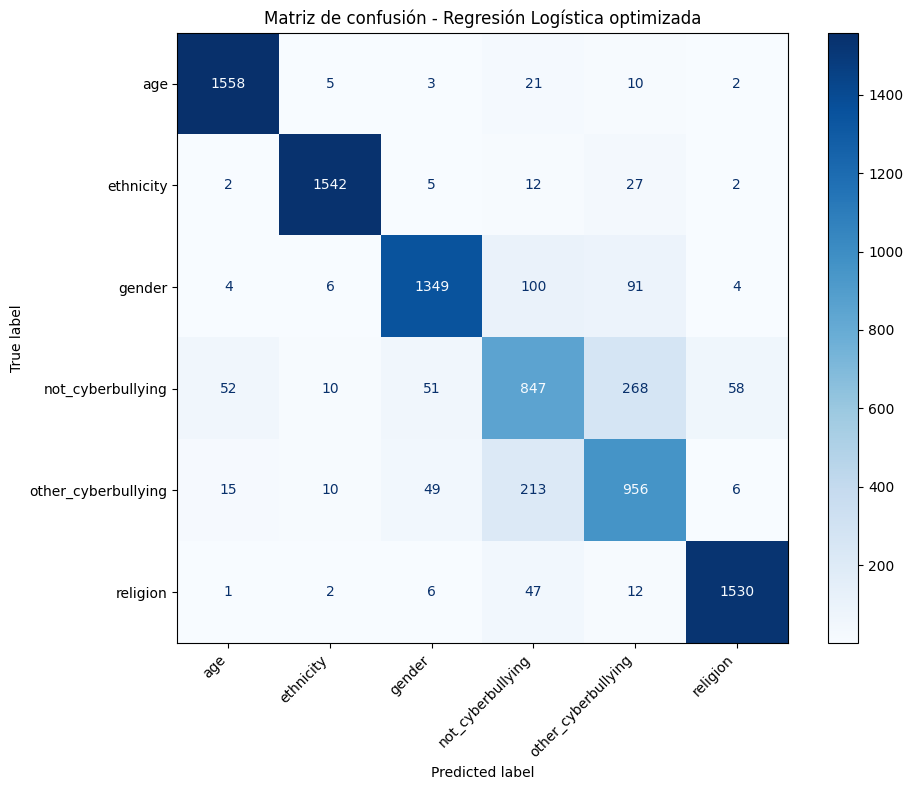

In [24]:
# ----------------------------------------------------------
# MATRIZ DE CONFUSIÓN DEL MODELO OPTIMIZADO
# ----------------------------------------------------------

# Obtenemos las categorías en el mismo orden
# utilizado por el modelo.
categorias = mejor_modelo.named_steps[
    "modelo"
].classes_

# Calculamos la matriz de confusión.
cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=categorias
)

# Creamos la visualización.
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categorias
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Matriz de confusión - Regresión Logística optimizada"
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión muestra que el modelo presenta una elevada capacidad de clasificación en las categorías más específicas.

Las categorías `age`, `ethnicity` y `religion` presentan un número muy elevado de predicciones correctas, en consonancia con los altos valores de F1 obtenidos para estas clases. La categoría `gender` también presenta un buen rendimiento, aunque muestra un mayor número de errores hacia las categorías genéricas.

La principal dificultad del modelo se concentra en la separación entre `not_cyberbullying` y `other_cyberbullying`. En concreto, 268 mensajes pertenecientes a `not_cyberbullying` fueron clasificados como `other_cyberbullying`, mientras que 213 mensajes de `other_cyberbullying` fueron clasificados como `not_cyberbullying`.

Este comportamiento es coherente con los resultados obtenidos durante el análisis exploratorio, donde la mayor parte de las inconsistencias de etiquetado del dataset original se concentraban precisamente entre estas dos categorías.

No obstante, esta relación debe interpretarse como una evidencia de la dificultad de separación entre ambas clases dentro de este dataset y no como una relación causal demostrada.

En conjunto, los resultados indican que el modelo identifica con elevada precisión las categorías temáticas más específicas, mientras que la principal limitación se encuentra en la frontera entre las dos categorías de carácter más general.

### Conclusión de la evaluación del modelo

Tras comparar diferentes algoritmos y representaciones del texto, la Regresión Logística optimizada mediante TF-IDF con unigramas y bigramas fue seleccionada como modelo final.

La optimización mediante validación cruzada seleccionó un valor `C = 2.0` y una representación `ngram_range = (1, 2)`.

Sobre el conjunto de test reservado, el modelo obtuvo:

- **Accuracy:** 0,8767
- **F1 Macro:** 0,8653
- **F1 Weighted:** 0,8771

Los resultados muestran un rendimiento especialmente elevado en las categorías `age`, `ethnicity` y `religion`, mientras que las mayores dificultades aparecen en la separación entre `not_cyberbullying` y `other_cyberbullying`.

Estos resultados permiten considerar el modelo adecuado como prototipo de clasificación automática del contenido textual analizado. Sin embargo, sus predicciones deben interpretarse como una herramienta de apoyo y no como una determinación definitiva de la existencia de ciberacoso, ya que el fenómeno puede depender de información contextual que no está contenida únicamente en el texto.

## Entrenamiento y almacenamiento del modelo para despliegue

Una vez seleccionada y evaluada la configuración final utilizando el conjunto de test reservado, se entrena una nueva instancia del Pipeline utilizando el conjunto completo de datos limpios.

Este reentrenamiento no se utiliza para calcular nuevas métricas de evaluación. Su finalidad es aprovechar todos los datos disponibles para generar el modelo que posteriormente será utilizado en la aplicación Streamlit.

Las métricas reportadas anteriormente corresponden exclusivamente a la evaluación realizada sobre el conjunto de test antes de este reentrenamiento.

In [25]:
# ----------------------------------------------------------
# MODELO DEFINITIVO PARA DESPLIEGUE
# ----------------------------------------------------------

modelo_despliegue = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=5,
            max_features=30000
        )
    ),

    (
        "modelo",
        LogisticRegression(
            C=2.0,
            max_iter=1000,
            random_state=42
        )
    )
])

# Entrenamos utilizando todos los datos limpios disponibles.
modelo_despliegue.fit(
    X,
    y
)

print(
    "Modelo de despliegue entrenado con",
    len(X),
    "observaciones."
)

Modelo de despliegue entrenado con 44378 observaciones.


In [26]:
# ----------------------------------------------------------
# GUARDADO DEL PIPELINE FINAL
# ----------------------------------------------------------

import joblib

nombre_modelo = "modelo_ciberacoso.pkl"

joblib.dump(
    modelo_despliegue,
    nombre_modelo
)

print(
    "Modelo guardado correctamente como:",
    nombre_modelo
)

Modelo guardado correctamente como: modelo_ciberacoso.pkl


In [27]:
# ----------------------------------------------------------
# COMPROBACIÓN DEL MODELO GUARDADO
# ----------------------------------------------------------

# Volvemos a cargar el modelo desde el archivo .pkl
modelo_cargado = joblib.load(
    "modelo_ciberacoso.pkl"
)

# Creamos algunos textos de prueba.
# No se utilizan para medir el rendimiento del modelo;
# únicamente comprobamos que el Pipeline cargado
# funciona correctamente.

textos_prueba = [
    "I was bullied at school for years",
    "People should respect each other online"
]

predicciones_prueba = modelo_cargado.predict(
    textos_prueba
)

for texto, prediccion in zip(
    textos_prueba,
    predicciones_prueba
):
    print("Texto:", texto)
    print("Predicción:", prediccion)
    print("-" * 50)

Texto: I was bullied at school for years
Predicción: age
--------------------------------------------------
Texto: People should respect each other online
Predicción: other_cyberbullying
--------------------------------------------------


## Conclusión del notebook

En este notebook se desarrolló el proceso completo de construcción del modelo de clasificación textual.

Se compararon tres algoritmos de Machine Learning clásico —Regresión Logística, Multinomial Naive Bayes y Linear SVM— utilizando una representación TF-IDF común. Posteriormente, se evaluó la incorporación de bigramas en los dos modelos con mejor rendimiento.

La Regresión Logística obtuvo los mejores resultados globales y fue optimizada mediante validación cruzada. La configuración seleccionada utilizó unigramas y bigramas y un valor de regularización `C = 2.0`.

El modelo evaluado sobre el conjunto de test obtuvo un Accuracy de 0,8767 y un F1 Macro de 0,8653.

El análisis por categoría mostró un rendimiento especialmente elevado en las clases asociadas a edad, etnia y religión, mientras que la mayor dificultad de clasificación se concentró entre las categorías `not_cyberbullying` y `other_cyberbullying`.

Una vez completada la evaluación, se entrenó el Pipeline definitivo utilizando las 44.378 observaciones limpias disponibles y se almacenó en el archivo `modelo_ciberacoso.pkl` para su posterior integración en la aplicación desarrollada con Streamlit.

In [28]:
from google.colab import files

files.download("modelo_ciberacoso.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>